# Tarea 1 - Análisis de Rendimiento y Riesgo de Activos Financieros

**Materia:** Portafolios de Inversión  
**Activos analizados:** PRGO, PLTR y BRK-B  
**Periodo de análisis:** 01/01/2018 - 30/08/2026

## 1. Investigación de las emisoras

### PRGO - Perrigo Company plc

#### ¿A qué se dedica?

#### Sector económico según GICS

#### Principales competidores

#### Estado de Resultados

#### Balance General

#### Flujo de Efectivo


### PLTR - Palantir Technologies Inc.

#### ¿A qué se dedica?

#### Sector económico según GICS

#### Principales competidores

#### Estado de Resultados

#### Balance General

#### Flujo de Efectivo


### BRK-B - Berkshire Hathaway Inc.

#### ¿A qué se dedica?

#### Sector económico según GICS

#### Principales competidores

#### Estado de Resultados

#### Balance General

#### Flujo de Efectivo


## 2. Importacion de datos y revisión

In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
tickers = ['PRGO', 'PLTR', 'BRK-B']

### Descarga de precios

In [23]:
prices = yf.download(tickers, start='2018-01-01', end='2026-08-24')["Close"]

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_27192/3670712845.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start='2018-01-01', end='2026-08-24')["Close"]
[*********************100%***********************]  3 of 3 completed


In [24]:
prices

Ticker,BRK-B,PLTR,PRGO
Date,,,
2018-01-02,197.220001,NaN,68.452705
2018-01-03,199.789993,NaN,68.261894
2018-01-04,200.690002,NaN,69.513565
2018-01-05,201.419998,NaN,69.589897
2018-01-08,202.740005,NaN,68.788498
...,...,...,...
2026-08-17,498.230011,172.550003,12.561280
2026-08-18,502.959991,171.539993,12.708254
2026-08-19,499.619995,175.190002,13.678274


In [25]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2171 entries, 2018-01-02 to 2026-08-21
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BRK-B   2171 non-null   float64
 1   PLTR    1480 non-null   float64
 2   PRGO    2171 non-null   float64
dtypes: float64(3)
memory usage: 67.8 KB


In [26]:
prices.describe()


Ticker,BRK-B,PLTR,PRGO
count,2171.000000,1480.000000,2171.000000
mean,319.572727,53.454520,33.126843
std,110.422167,57.661437,12.485289
min,162.130005,6.000000,8.833573
25%,213.130005,14.137500,25.286529
50%,293.239990,23.660000,32.208107
75%,414.740005,86.134998,38.575024
max,539.799988,207.179993,72.619843


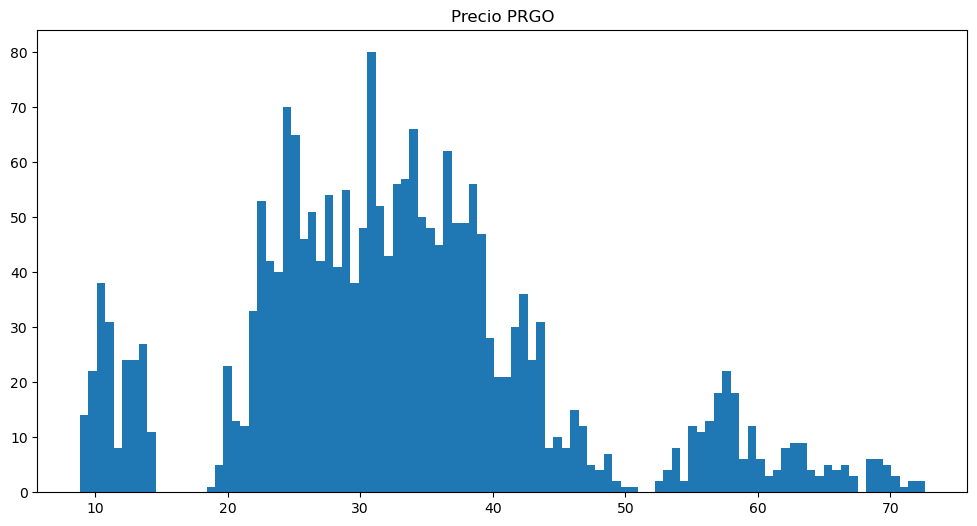

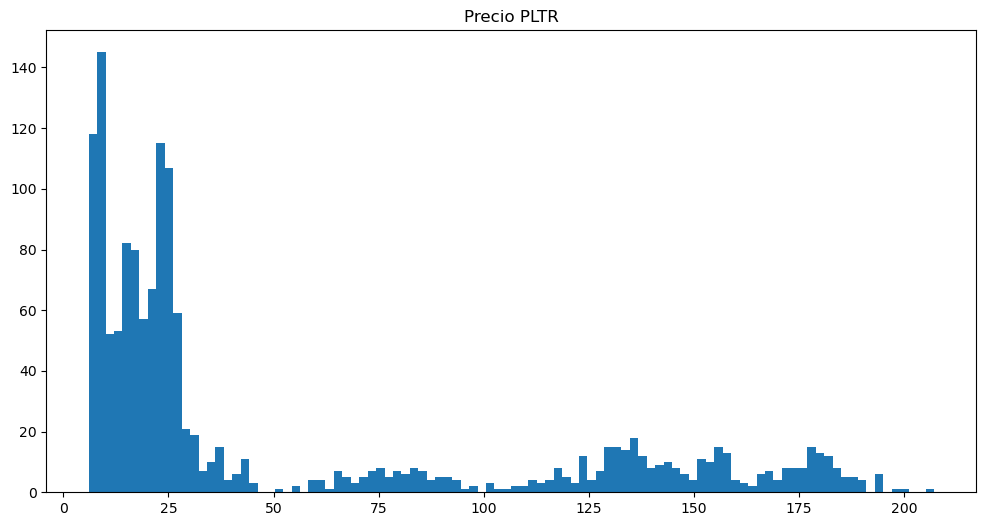

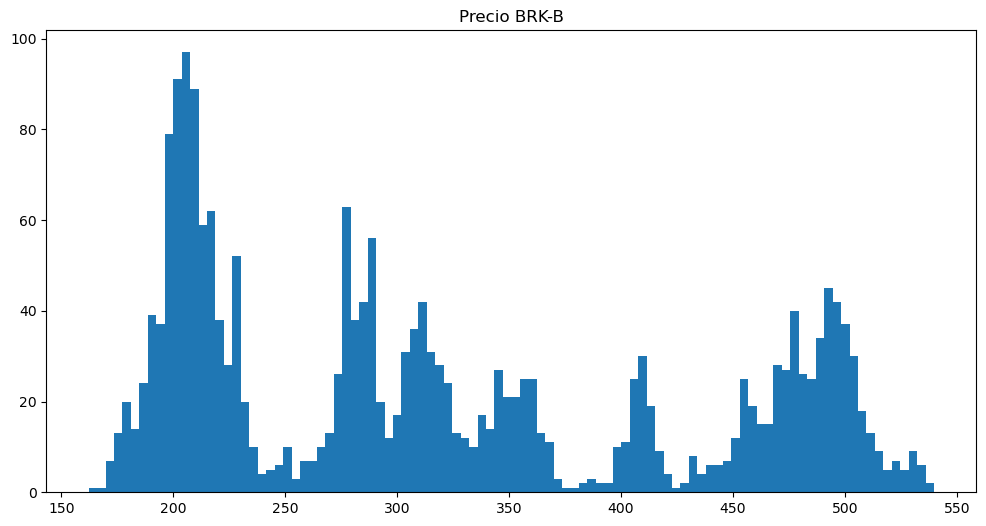

In [27]:
for i in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(prices[i], bins=100)
    plt.title(f'Precio {i}')
    plt.show(i)

## 3. Cálculo y Gráfica de la distribución de los rendimientos diarios 

In [28]:
daily_rets=prices/prices.shift()-1

In [29]:
daily_rets

Ticker,BRK-B,PLTR,PRGO
Date,,,
2018-01-02,NaN,NaN,NaN
2018-01-03,0.013031,NaN,-0.002787
2018-01-04,0.004505,NaN,0.018336
2018-01-05,0.003637,NaN,0.001098
2018-01-08,0.006554,NaN,-0.011516
...,...,...,...
2026-08-17,-0.011507,-0.008561,-0.016871
2026-08-18,0.009494,-0.005853,0.011701
2026-08-19,-0.006641,0.021278,0.076330


### Distribución de rendimientos diarios

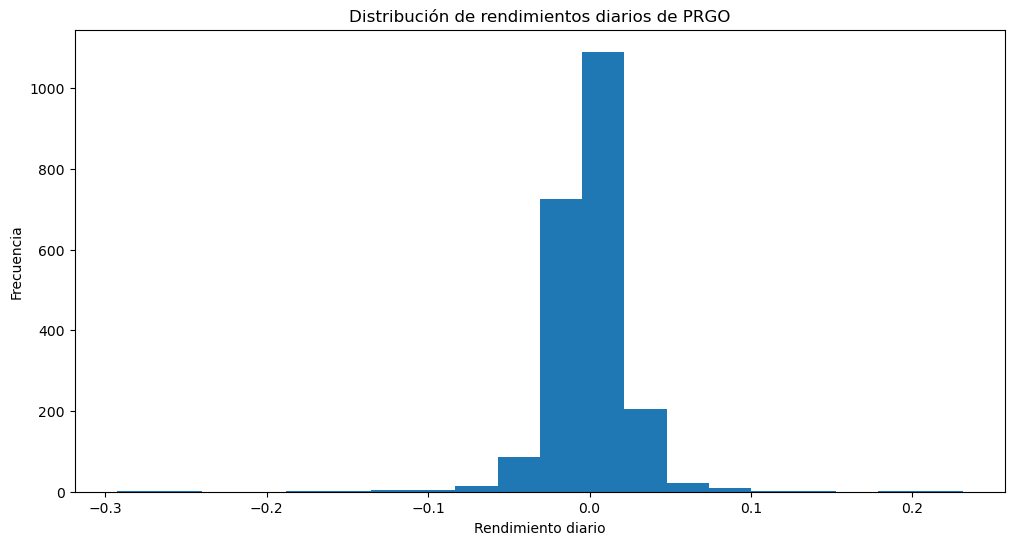

In [30]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['PRGO'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de PRGO')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

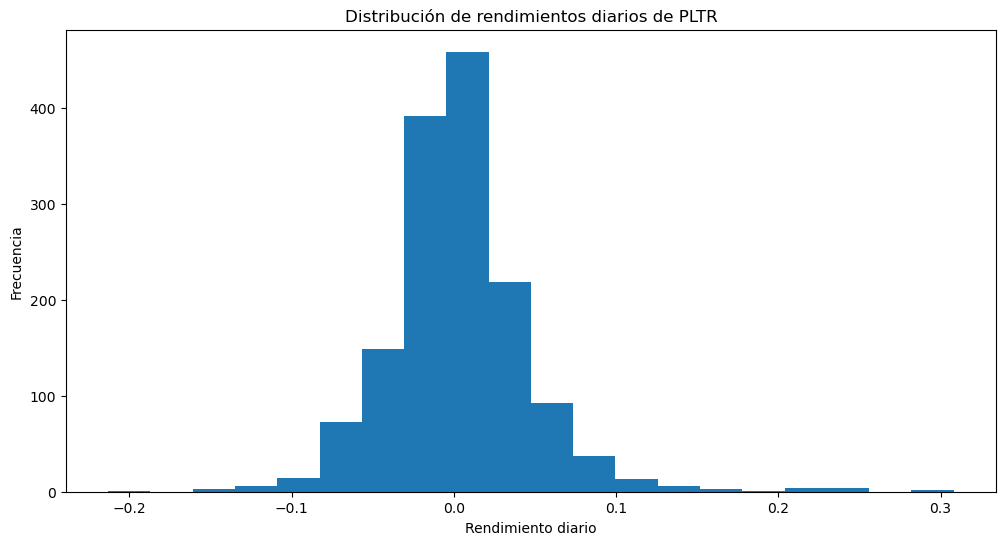

In [31]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['PLTR'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de PLTR')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

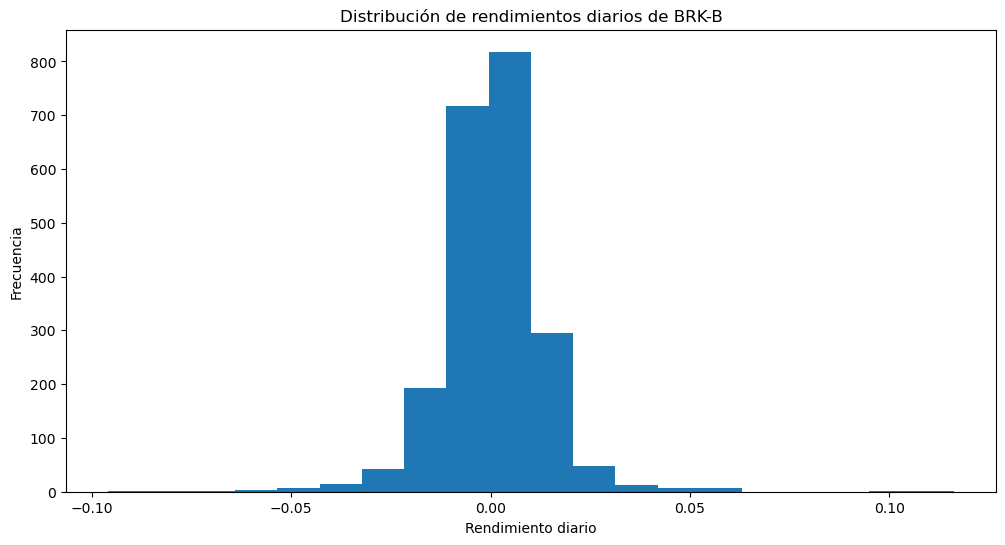

In [32]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['BRK-B'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de BRK-B')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

## 4. Rendimiento promedio anual

In [33]:
daily_mean=daily_rets.mean()
daily_mean*100


Ticker
BRK-B    0.050762
PLTR     0.294400
PRGO    -0.042378
dtype: float64

In [34]:
annual_mean=daily_mean*252
annual_mean*100

Ticker
BRK-B    12.791914
PLTR     74.188706
PRGO    -10.679290
dtype: float64

En el periodo analizado el activo que presenta un mayor rendimiento promedio anual con un 74.18% es PLTR, BRK-B con un 12.79% y PRGO con rendimiento anual promedio negativo de -10.67% lo que nos dice que en en promedio su comportamiento fue desfavorable para un inversionista

## 5. Riesgo anual

### Varianza anual

In [35]:
daily_variance=daily_rets.var()
annual_variance=daily_variance*252
annual_variance*100

Ticker
BRK-B     4.164391
PLTR     49.485867
PRGO     15.169190
dtype: float64

Las unidades de la varianza no se pueden interpretar directamente   
por lo que se recomienda calcular la desviación estándar, que es la raíz cuadrada de la varianza.   
La desviación estándar nos da una idea de la dispersión de los datos y se puede interpretar en las mismas unidades que los datos originales.

### Volatilidad anual

In [36]:
daily_volatility=daily_rets.std()
daily_volatility*100

Ticker
BRK-B    1.285510
PLTR     4.431394
PRGO     2.453471
dtype: float64

In [37]:
volatility_annual=daily_volatility*np.sqrt(252)
volatility_annual*100

Ticker
BRK-B    20.406840
PLTR     70.346192
PRGO     38.947644
dtype: float64

La volatilidad nos dice que tanto varían los rendimientos repecto a su media, en este caso el que tiene la volatilidad mas alta es PLTR con un 70.34% y luego PRGO con un 38.94% y la mas baja la tiene BRK-B con un 20.40% por lo que es el activo mas estable y menos riesgoso

### Coeficiente de Variación

In [38]:
CV=volatility_annual/annual_mean
CV

Ticker
BRK-B    1.595292
PLTR     0.948206
PRGO    -3.647026
dtype: float64

PRGO no es una buena opción para esta comparación porque tiene un rendimiento anual promedio negativo,   
entonces su CV sale negativo, pero no por eso quiere decir que sea el mejor para escoger solo porque su CV sea el más bajo.

### Comparación de los activos

In [39]:
results= pd.DataFrame({
    'Rendimiento anual': annual_mean*100,
    'Volatilidad anual': volatility_annual*100,
    'CV': CV
})

results

,Rendimiento anual,Volatilidad anual,CV
Ticker,,,
BRK-B,12.791914,20.406840,1.595292
PLTR,74.188706,70.346192,0.948206
PRGO,-10.679290,38.947644,-3.647026


### ¿Qué activo es mejor?

El activo que hasta este punto parece mejor basandonos en la comparación es **PLTR** ya que aunque tiene la mayor volatilidad anual,tambien tiene el mejor rendimiento promedio anual y el menor CV por lo que tiene una mejor relación entre el riesgo y rendimientos



## 6. Asimetría

In [40]:
daily_rets.skew()

Ticker
BRK-B   -0.074943
PLTR     1.141987
PRGO    -0.977175
dtype: float64

Con estos resultados podemos interpretar:    
**1. BRK-B** tiene una asimetría casi = 0 (-0.07) por lo que su distribución pudiera ser casi simétrica aunque se inclina un poco mas a las perdidas.   
**2. PLTR** tiene una asimetría >0 por lo que es positiva (1.14) sus outliers estan mas cargados hacia las ganancias.   
**3. PRGO** tiene una asimetría <0 negativa (-0.9775) por lo que hay una mayor posibilidad de que aparezcan pérdidas extremas que ganancias extremas

## 7. Conclusión final

......